<img src="../_images/logos/seaborn.svg" width="200px">

# Seaborn - Topic 04 - Seaborn Plots: Part 02

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png"> 

## Topic Objectives

* Learn and deliver jointplot, LM plot, Scatter plot and Pair plot in Seaborn


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> 

## Import Packages for Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

## Topic 04 - Seaborn Plots: Part 02

We will cover in this topic the following plots:
* Jointplot
* LM plot
* Scatter plot
* Pair plot

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Jointplot

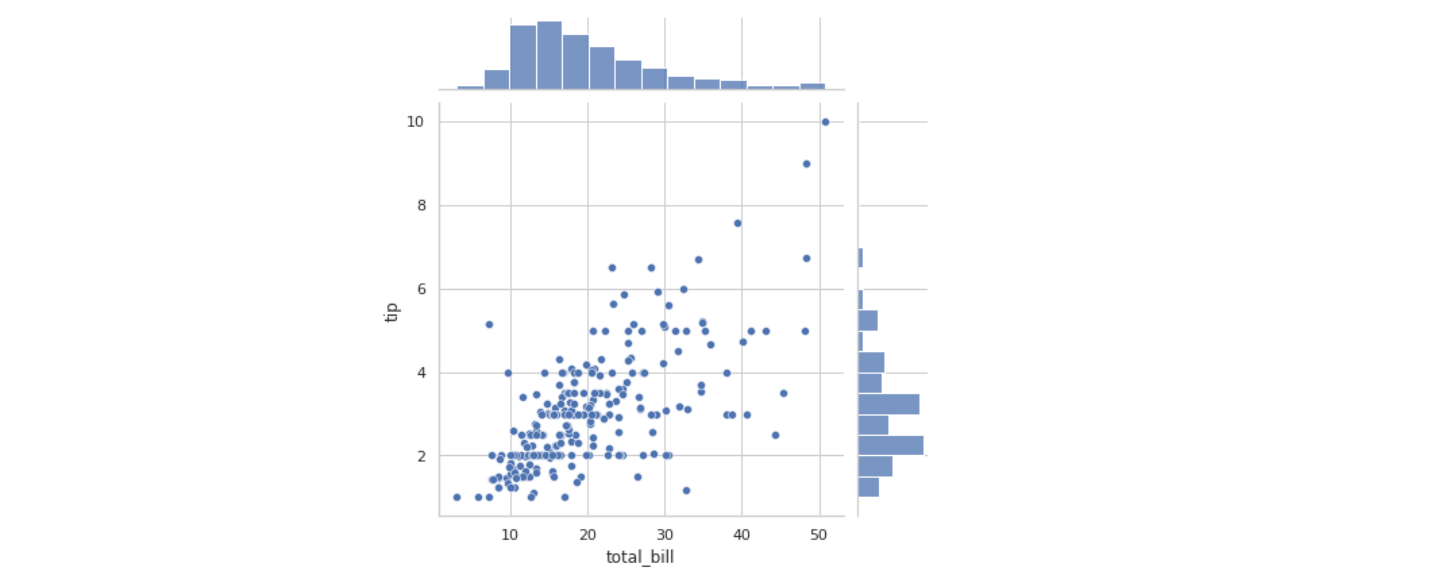

**Use Case:** `jointplot` is used to simultaneously display a scatter plot (or other types) along with the marginal distributions of each variable (typically histograms or KDE plots). This is particularly useful for analyzing bivariate relationships along with the individual univariate distributions in the same visualisation.

* **When to Use:** Useful when you need to analyze the relationship between two continuous variables while also inspecting their individual distributions.
* **Example Application:** Exploring the relationship between variables like height and weight, or price and quality ratings, where understanding both the correlation and the distribution of each variable independently is important.

Consider the tips dataset. It holds records for waiter tips based on the day of the week, time of day, total bill, gender, if it is a table of smokers or not, and how many people were at the table.

In [2]:
df = sns.load_dataset('tips')
df.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


You are interested in drawing a plot of two variables with bivariate and univariate graphs at the same time. You can use ``sns.jointplot()``; the documentation is [here](https://seaborn.pydata.org/generated/seaborn.jointplot.html)
* The result is a scatter plot and two histograms, so you can visualise how the variables correlate and are distributed
* The arguments are ``data``, and ``x`` and ``y`` are the numerical variables you are interested in studying
* You will notice a general trend where the tips tend to increase when the total bill increases

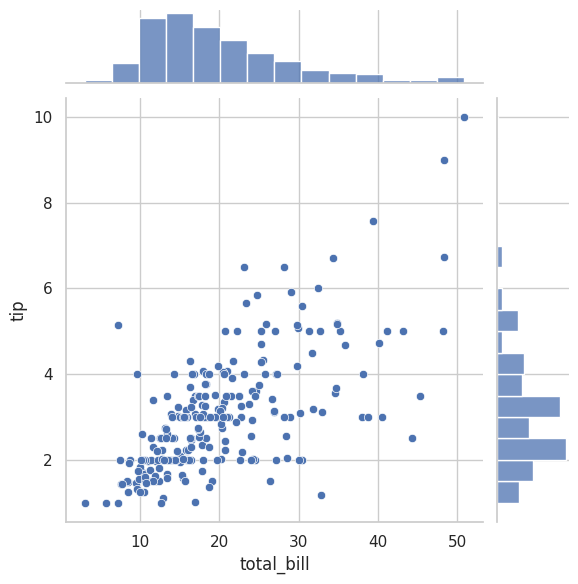

In [3]:
sns.set_theme(style="whitegrid")
sns.jointplot(data=df, y='tip', x='total_bill')
plt.show()

You can include an additional dimension with ``hue`` to set a variable that maps the colour of the data points and the distribution

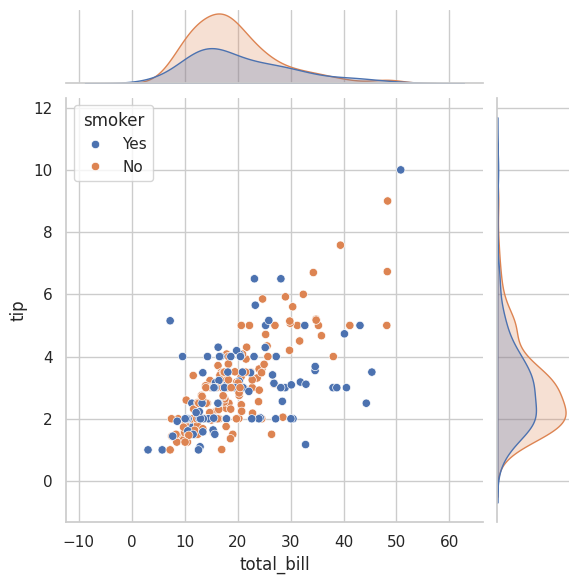

In [4]:
sns.jointplot(data=df, y='tip', x='total_bill', hue='smoker')
plt.show()

There is a parameter called `kind`. When `kind='hex'`, it creates the "scatter plot" using hexagonal bins. The more intense the hexagonal bins, the more values of both numerical distributions are in that bin. It is helpful to assess in which ranges the pairs x and y are more frequent
* The plot says bills from 10 to almost 20 with tips from 2 to 3 are more common in this restaurant

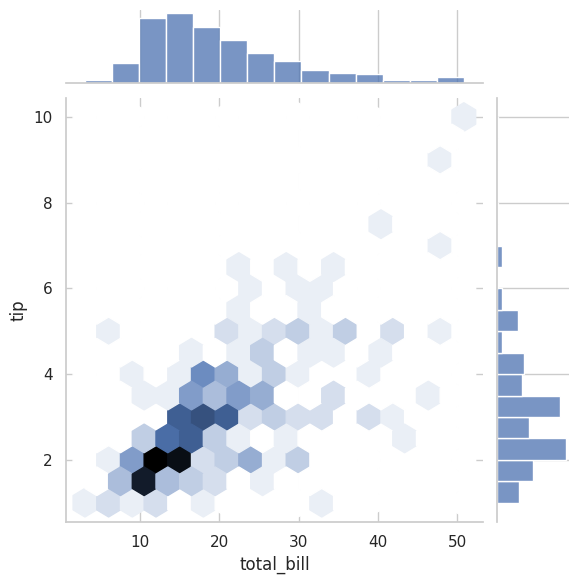

In [5]:
sns.jointplot(data=df, x='total_bill', y='tip', kind='hex')
plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: We will use the DataFrame below, which uses the 'insurance' dataset.

In [6]:
df_practice = pd.read_csv('data/insurance.csv')
df_practice = df_practice.sample(n=50, random_state=1)
df_practice.head(3)

,age,sex,bmi,children,smoker,region,charges
559,19,male,35.53,0,no,northwest,1646.4297
1087,57,male,31.54,0,no,northwest,11353.2276
1020,51,male,37.00,0,no,southwest,8798.5930


Feel free to try out your ideas or use the following suggestion.

You are interested in using a joinplot. You decide on using charges and the age colouring by smoker.

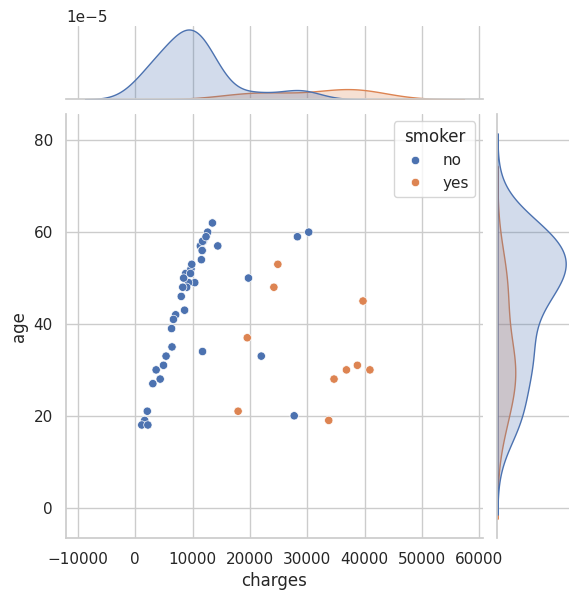

In [7]:
# write your code here
sns.jointplot(data=df_practice, x='charges', y='age', hue='smoker', kind='scatter')
plt.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### LM Plot

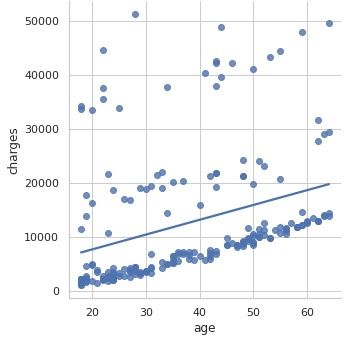

**Use Case:** `lmplot` combines regression models with scatter plots to provide an easy-to-use interface for fitting linear models to visual representations of data. 

* **When to Use:** When you want to visualise the linear relationship between variables and see how this relationship varies with the change in a categorical variable (like different groups or conditions).
* **Example Application:** Useful in business analytics for regression analysis like sales over time by different market segments, or in healthcare for plotting trends of medical measurements across different patient groups.

Consider the insurance dataset
  * It has records on the relationship between personal attributes (age, gender, BMI: body mass index, family size, smoking habits), geographic factors, and their impact on medical insurance charges.

In [8]:
df = pd.read_csv('data/insurance.csv')
df = df.sample(n=200, random_state=5)
df.head(3)

,age,sex,bmi,children,smoker,region,charges
471,18,female,30.115,0,no,northeast,2203.47185
1250,24,male,29.830,0,yes,northeast,18648.42170
1257,54,female,27.645,1,no,northwest,11305.93455


You are interested in plotting a Scatter plot and fitting and visualising a Regression model of your data. You will not assess the fitted model itself; the idea is to visualise how a linear model would fit.
* You can use `sns.lmplot()`; the documentation is [here](https://seaborn.pydata.org/generated/seaborn.lmplot.html). This is a Figure level plot.
* The arguments are: ``data``, ``x`` and ``y`` are the variables you are interested in. 

* You will notice a positive and linear trend between the variables

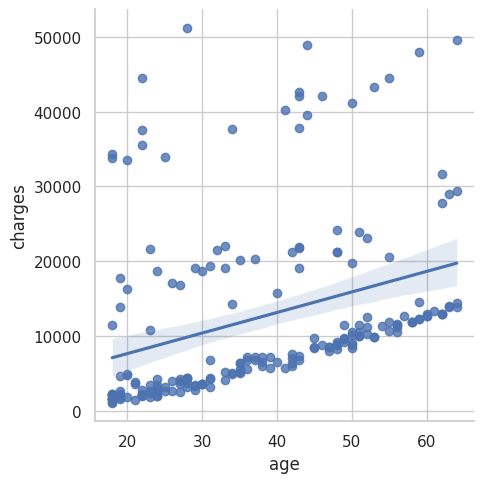

In [9]:
sns.lmplot(data=df, x="age", y="charges")
plt.show()

`ci` is the size of the confidence interval for the regression estimate. This will be drawn using translucent bands around the regression line. You may set it to `None`. 
* In the plot above, you will notice the line with band are biased towards higher outliers, in general, smokers.

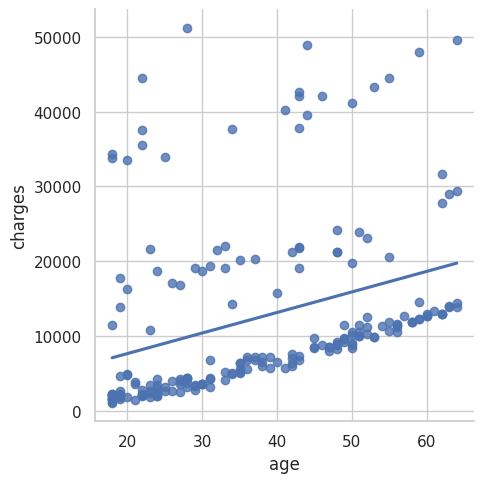

In [10]:
sns.lmplot(data=df, x="age", y="charges", ci=None )
plt.show()

You can facet your data with `col` and `row` arguments. That will create sub-plots and will facet the graphs according to the new variable information
* In this case, either smokers or non-smokers subsets show linear behaviour between the studied variables

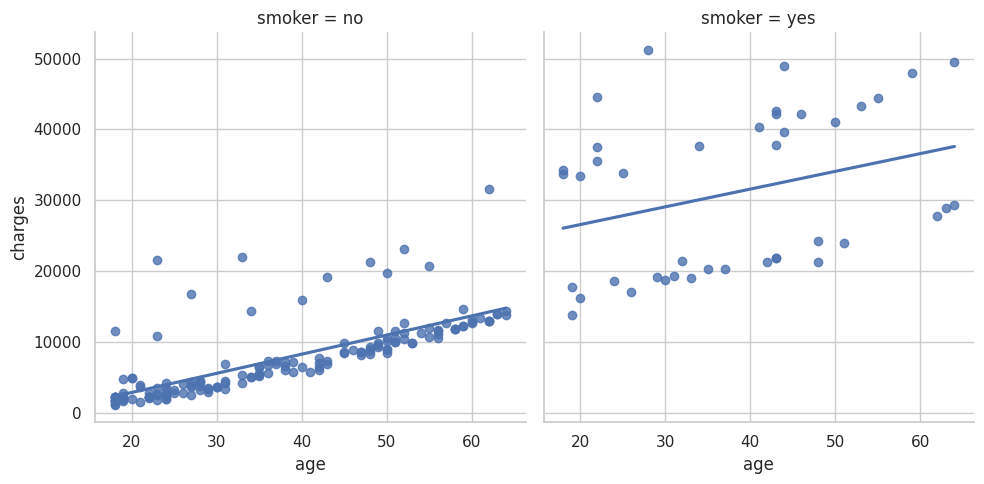

In [11]:
sns.lmplot(data=df, x="age", y="charges", col="smoker", ci=None)
plt.show()

You can facet by row, adding the parameter row
* Note that in the region subsets the trend slope between the studied variables varies

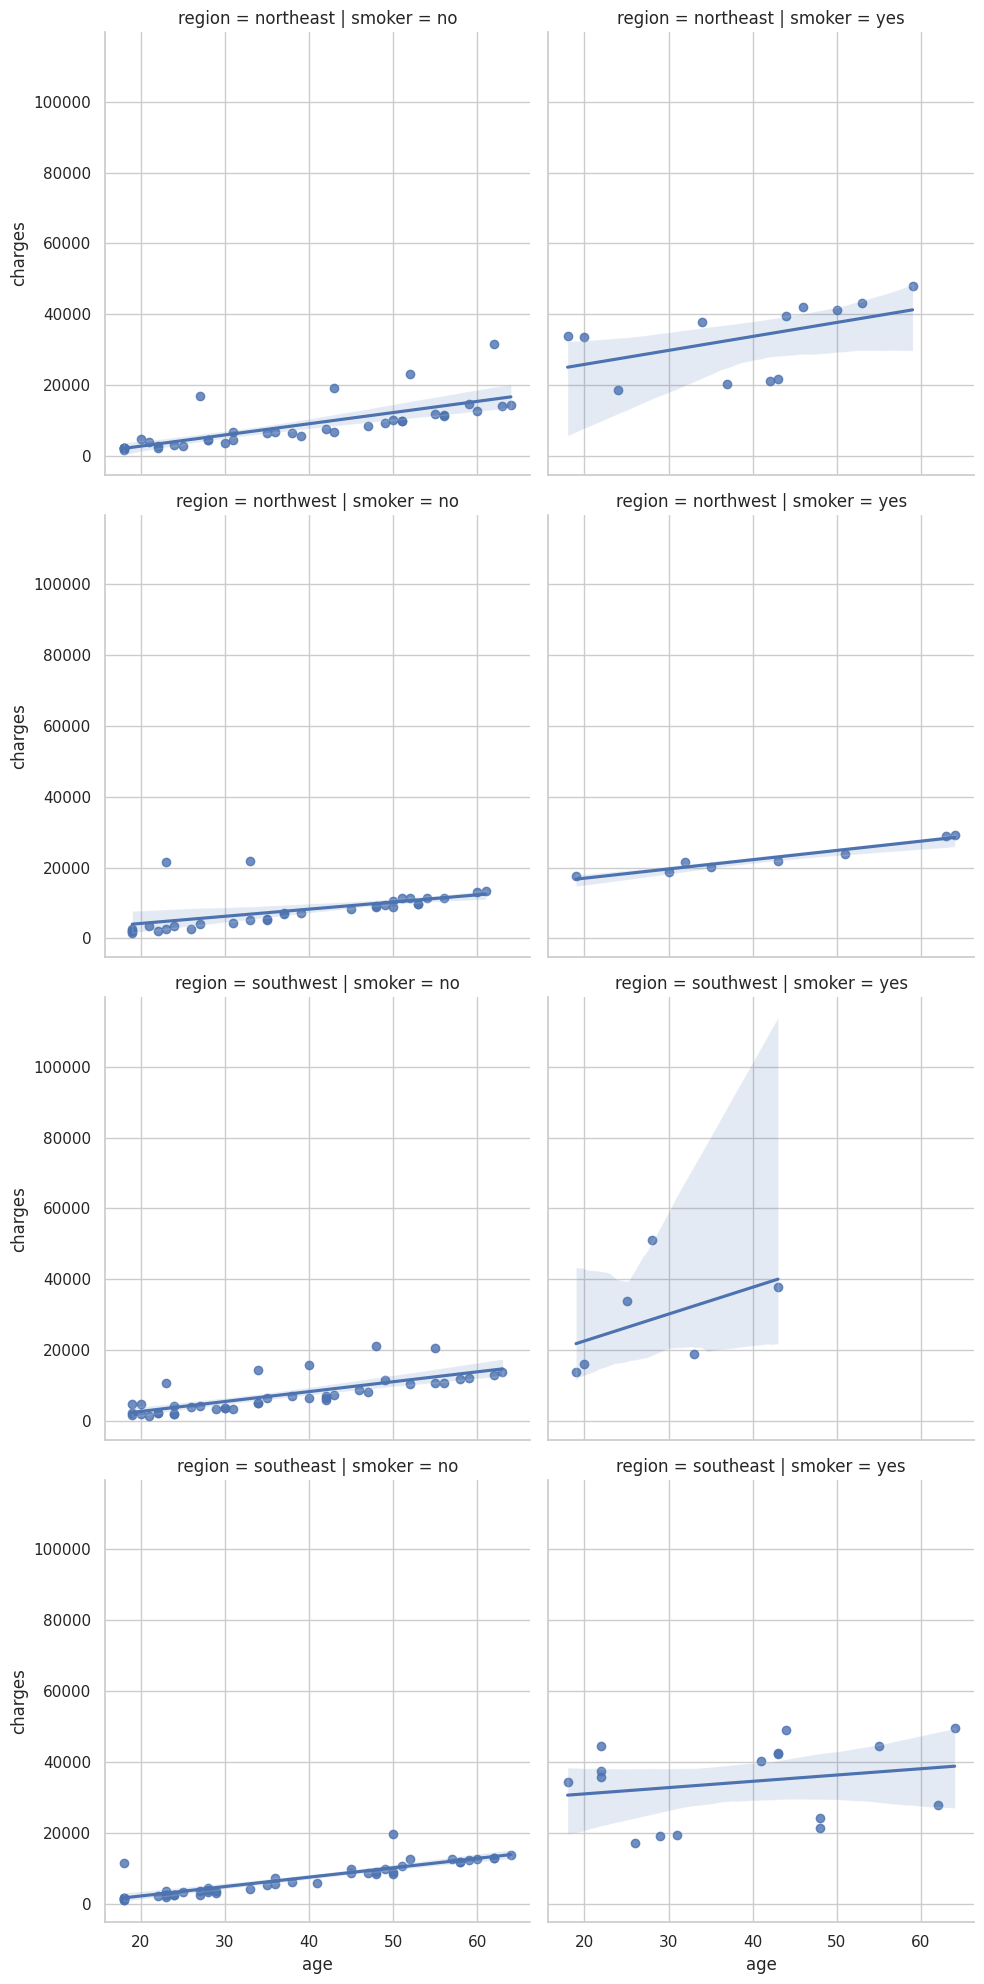

In [12]:
sns.lmplot(data=df, x="age", y="charges", col="smoker",row='region')
plt.show()

You can conduct Multiple Linear Regressions. You need to add the hue parameter to subset your data and fit multiple linear models on different subsets from the studied variables.

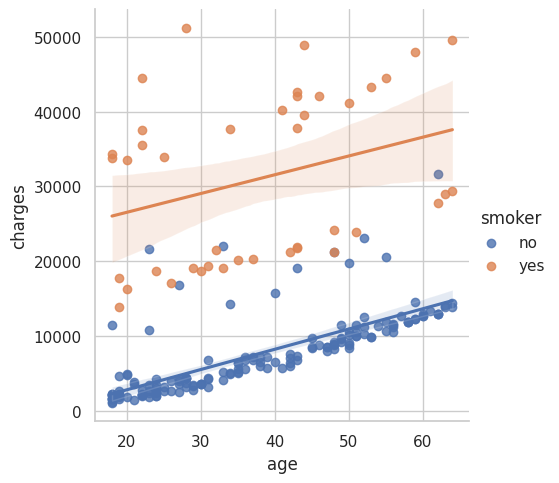

In [13]:
sns.lmplot(data=df,  x="age", y="charges", hue="smoker")
plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png">

**PRACTICE**: We will use the DataFrame below, which uses the tips dataset.

In [14]:
df_practice = sns.load_dataset('tips')
df_practice = df_practice.sample(n=50, random_state=1)
df_practice.head(3)

,total_bill,tip,sex,smoker,day,time,size
67,3.07,1.00,Female,Yes,Sat,Dinner,1
243,18.78,3.00,Female,No,Thur,Dinner,2
206,26.59,3.41,Male,Yes,Sat,Dinner,3


Feel free to try out your ideas or use the following suggestion.

You are interested in using a lmplot. You decide on using the tip and the total_bill colouring by sex.

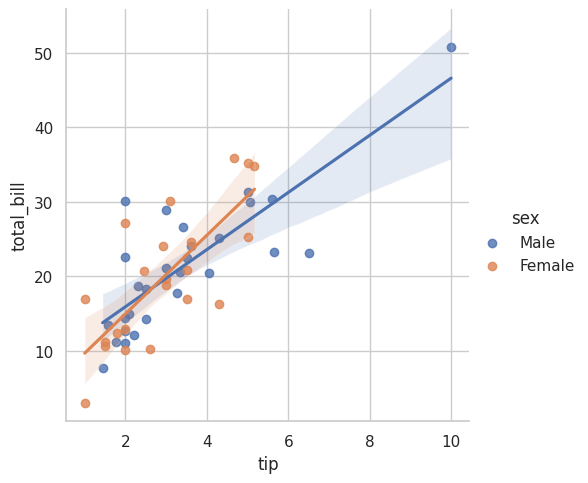

In [15]:
# write your code here
sns.lmplot(data=df_practice, x="tip", y="total_bill", hue="sex")
plt.show()

---

You can fit different kinds of models that are not linear and straight. That is useful when you notice the variables' relationships are not straight and linear.
* We consider the UK_Macrodata dataset to illustrate the example.

In [16]:
df = pd.read_csv('data/UK_MacroData.csv')
df.head(3)

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments)
0,2000 Q1,401242,1.1,5.875,69114.0
1,2000 Q2,404196,1.0,6.000,73074.0
2,2000 Q3,406795,1.2,6.000,68011.0


We parse x and y
* We notice the fitted line is not a good representation of the data

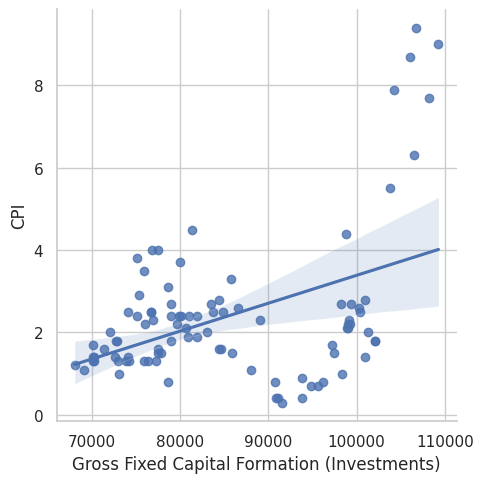

In [17]:
sns.lmplot(data=df, x="Gross Fixed Capital Formation (Investments)", y="CPI")
plt.show()

We can use an `order` argument. When it is greater than 1, it uses an internal function to estimate a polynomial regression. The `order` argument sets the order of the polynomial regression. When `order=1`, which is the default value, it is a linear regression
* We notice the fitted line is now a better representation of the data. That gives you insights into which type of algorithm could potentially fit your data

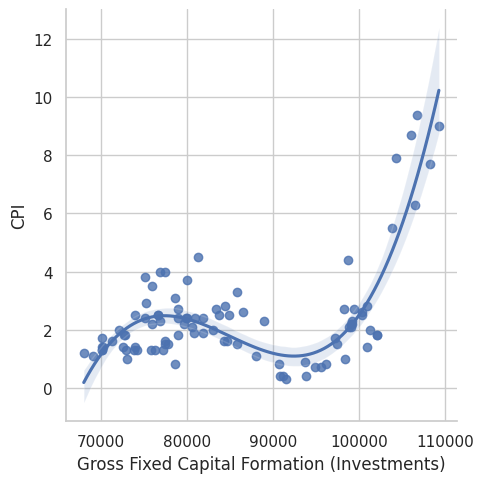

In [18]:
sns.lmplot(x="Gross Fixed Capital Formation (Investments)", y="CPI", data=df, order=3)
plt.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Scatter Plot

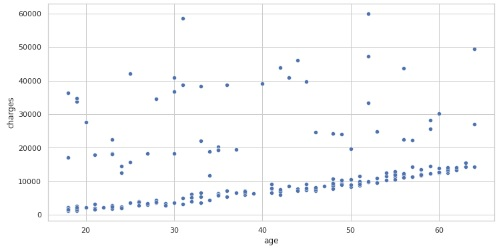

We use the 'insurance' dataset. It has records on the relationship between personal attributes (age, gender, BMI: body mass index, family size, smoking habits), geographic factors, and their impact on medical insurance charges

In [19]:
df = pd.read_csv('data/insurance.csv')
df = df.sample(n=200, random_state=1)
df.head(3)

,age,sex,bmi,children,smoker,region,charges
559,19,male,35.53,0,no,northwest,1646.4297
1087,57,male,31.54,0,no,northwest,11353.2276
1020,51,male,37.00,0,no,southwest,8798.5930


We use sns.scatterplot(); the documentation is [here](https://seaborn.pydata.org/generated/seaborn.scatterplot.html); This is a Axes level function.
* The arguments are: ``data``, ``x`` and ``y`` are the variables you are interested to study

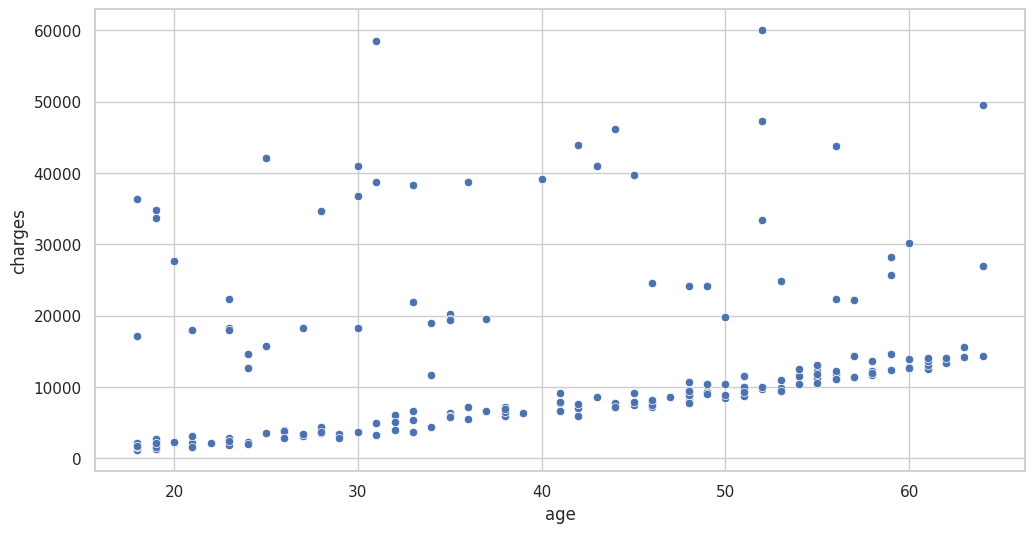

In [20]:
fig, axes = plt.subplots(figsize=(12,6))
sns.scatterplot(data=df, x='age', y='charges')
plt.show()

Notice you can use a categorical variable. It may not be the ideal way to plot the data, but the function accepts it.
* As an alternative, you could probably consider a box plot or swarmplot to study 'charges' and 'region'

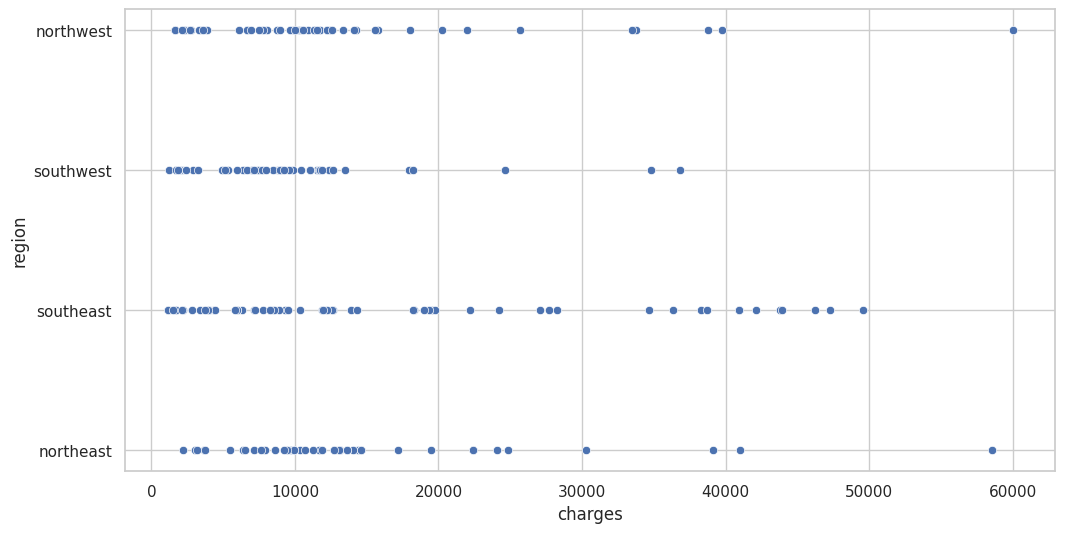

In [21]:
fig, axes = plt.subplots(figsize=(12,6))
sns.scatterplot(data=df, x='charges', y='region')
plt.show()

You can add the parameter `hue` to assess levels per a given category

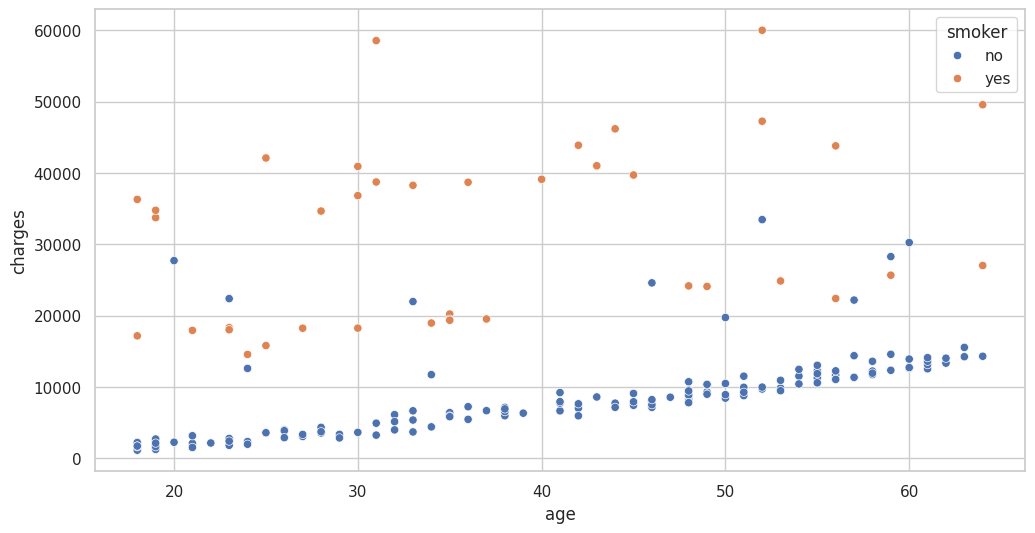

In [22]:
fig, axes = plt.subplots(figsize=(12,6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.show()

If you use a numerical variable when using ``hue``, it works also. It creates a coloured range based on the ``hue`` variable and colours the data points accordingly.
* In this case, we selected `bmi` for `hue`
* You may notice a pattern that `bmi` has high values when studied together with `'charges'`

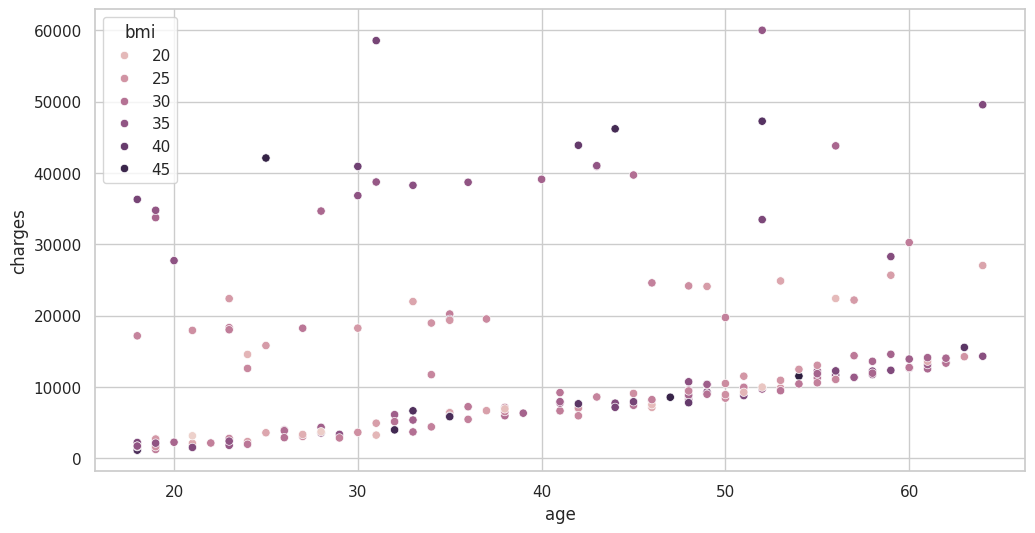

In [23]:
fig, axes = plt.subplots(figsize=(12,6))
sns.scatterplot(data=df, x='age', y='charges', hue='bmi')
plt.show()

You can add the parameter `size`. It groups data to generate points with different sizes.

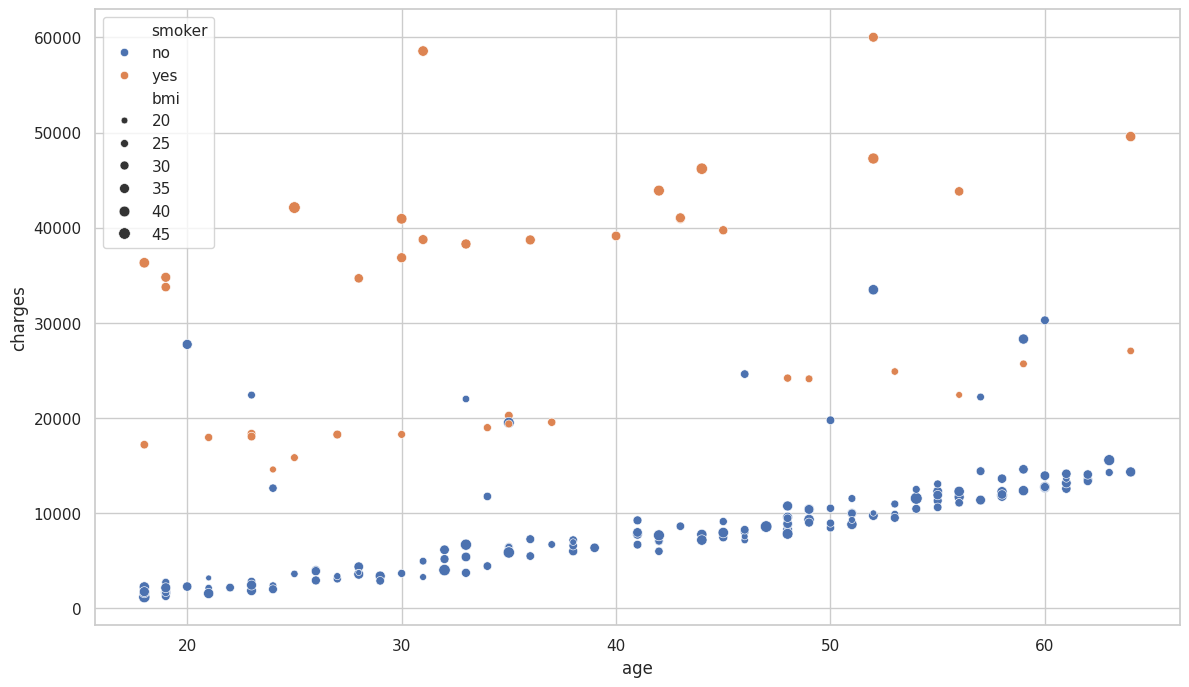

In [24]:
fig, axes = plt.subplots(figsize=(14,8))
sns.scatterplot(data=df, x='age', y='charges',
                hue='smoker',
                size='bmi')
plt.show()

The `size` argument determines how sizes are chosen. When the size is numeric, it can be a tuple specifying the minimum and maximum size to use, so the values are normalized within this range.
 * We randomly selected 40 and 200 as the min and max dot sizes. It is a matter of trial and error to validate what is suitable for your plot
 * We also added the parameter `alpha` to give a transparency effect when datapoints overlap. `alpha` takes values from 0.0 to 1.0

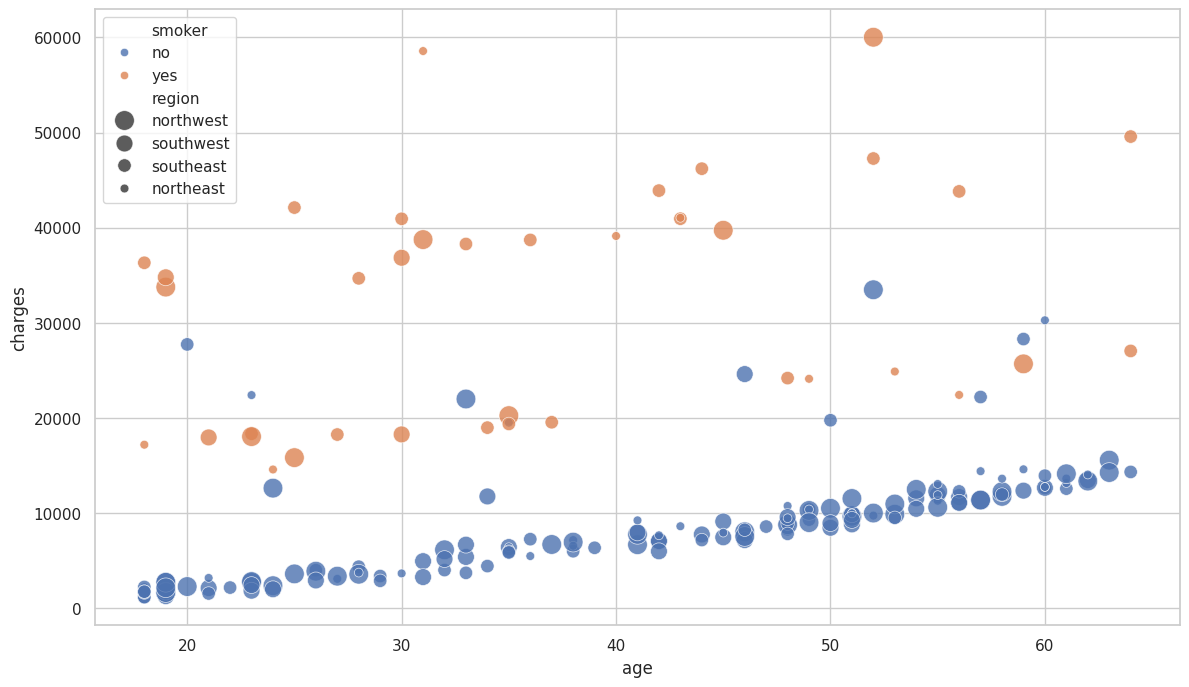

In [25]:
fig, axes = plt.subplots(figsize=(14,8))
sns.scatterplot(data=df, x='age', y='charges',
                hue='smoker',
                size='region', sizes=(40, 200),
                alpha=0.8)
plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: We will use the DataFrame below, which uses the CarPrice dataset. It holds records for different types of cars across the America market

In [26]:
df_practice = pd.read_csv("data/CarPrice_Assignment.csv")
df_practice.head(3)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0


Feel free to try out your ideas using scatter plot in this dataset

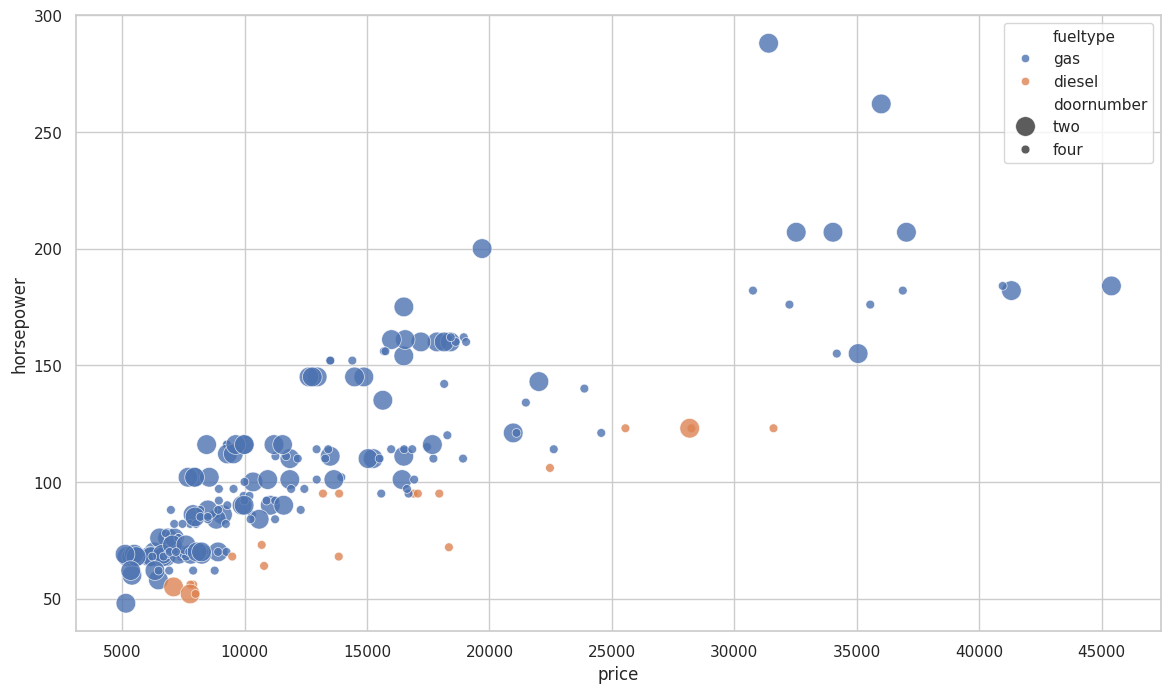

In [27]:
# write your code here
fig, axes = plt.subplots(figsize=(14,8))
sns.scatterplot(data=df_practice, x='price', y='horsepower',
                hue='fueltype',
                size='doornumber', sizes=(40, 200),
                alpha=0.8)
plt.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Pair Plot

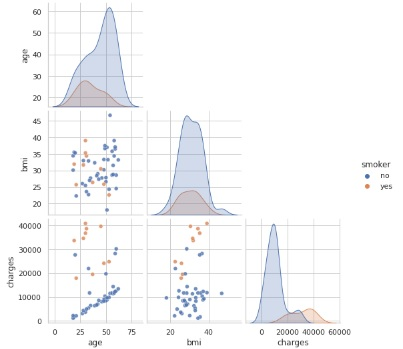

**Use Case:** `pairplot` visualises pairwise relationships across an entire dataframe (for the numerical columns) and supports a colour hue for different classes of a categorical variable. It creates a matrix of axes and shows the relationship for each pair of columns in a DataFrame. Along the diagonal, it shows the distribution of the data for that variable. A Pairplot aims to show pairwise relationships in a dataset by creating multiple plots so that each numeric variable in the data will be shared across themselves in a scatter plot. The diagonal plots are univariate distribution plots from each numerical variable.

* **When to Use:** Highly useful in exploratory data analysis where you need a quick and broad overview of the relationships within a dataset, particularly when trying to identify patterns, correlations, and potential hypotheses for deeper analysis.
* **Example Application:** Useful in in finance for analysing the relationships between different stocks' returns.

* Consider the insurance dataset. It contains records on the relationship between personal attributes (age, gender, BMI: body mass index, family size, smoking habits), geographic factors, and their impact on medical insurance charges

In [28]:
df = pd.read_csv("data/insurance.csv")
df = df.sample(n=50, random_state=1)
df['children'] = df['children'].astype('str')
df.head(3)

,age,sex,bmi,children,smoker,region,charges
559,19,male,35.53,0,no,northwest,1646.4297
1087,57,male,31.54,0,no,northwest,11353.2276
1020,51,male,37.00,0,no,southwest,8798.5930


You are interested in evaluating how your numerical and categorical variables correlate. You can use ``sns.pairplot()``; the documentation is  [here](https://seaborn.pydata.org/generated/seaborn.pairplot.html). It is a Figure level plot.
* The arguments are data; ``plot_kws={alpha}`` sets the transparency across the data points since they typically tend to overlap in this plot. By default, it will plot numerical data

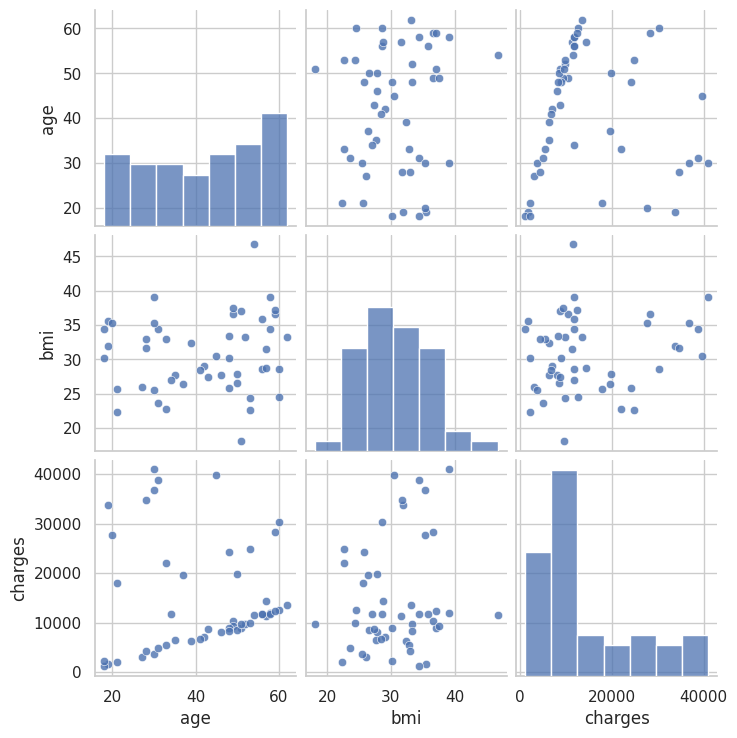

In [29]:
sns.pairplot(data=df, plot_kws={'alpha':0.8})
plt.show()

You will notice the upper part of the plot is repeated (inverted axes respectively), so we added a piece of code to remove it. The lower part is typically enough to analyze the data
* You noticed we created a variable fig, which is the Figure
* This additional piece of code loops over the Figure's plots, more specifically over the upper triangle and sets its visibility to false

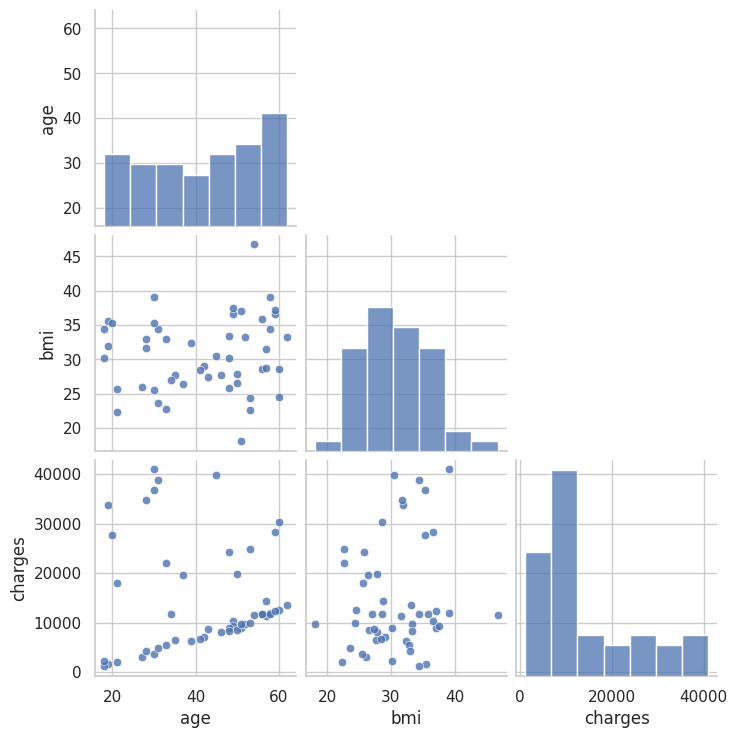

In [30]:
fig = sns.pairplot(data=df, plot_kws={'alpha':0.8});
for i, j in zip(*np.triu_indices_from(fig.axes, 1)):  # the loop removes the upper triangle part
  fig.axes[i, j].set_visible(False)
plt.show()

There will be use cases where you are interested to see how the data changes in a categorical variable. 
  * You can use a pairplot and set the parameter `hue` as your categorical variable

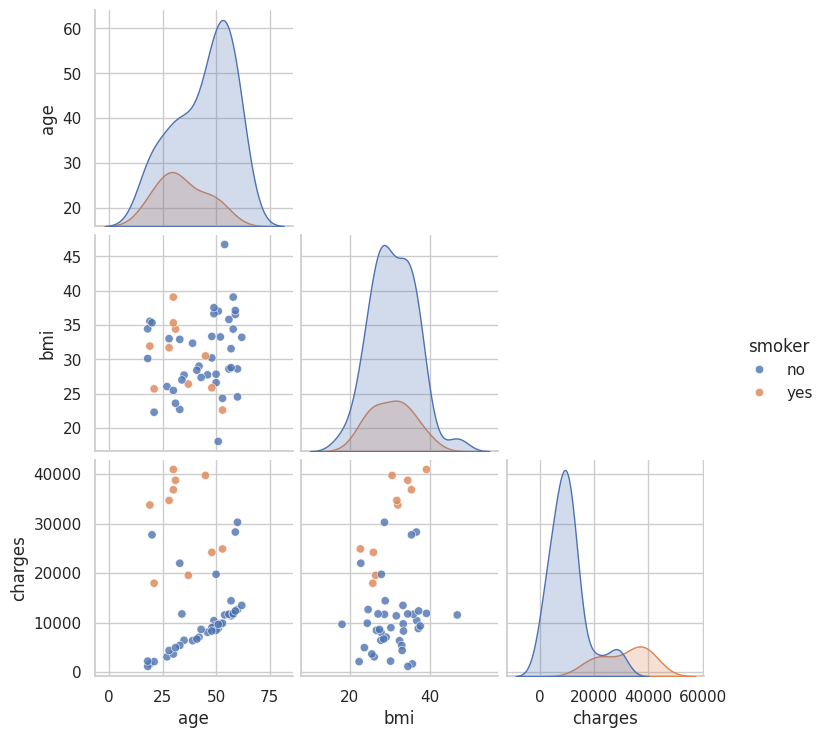

In [31]:
fig = sns.pairplot(data=df, plot_kws={'alpha':0.8}, hue="smoker");
for i, j in zip(*np.triu_indices_from(fig.axes, 1)):
  fig.axes[i, j].set_visible(False)
plt.show()

As a reinforcement, in Seaborn, you can use [Matplolib palette](https://matplotlib.org/stable/tutorials/colors/colormaps.html) colours to customise your plot. Seaborn also has its own [palette options](https://seaborn.pydata.org/tutorial/color_palettes.html)

* In this example, we considered `palette='crest'`

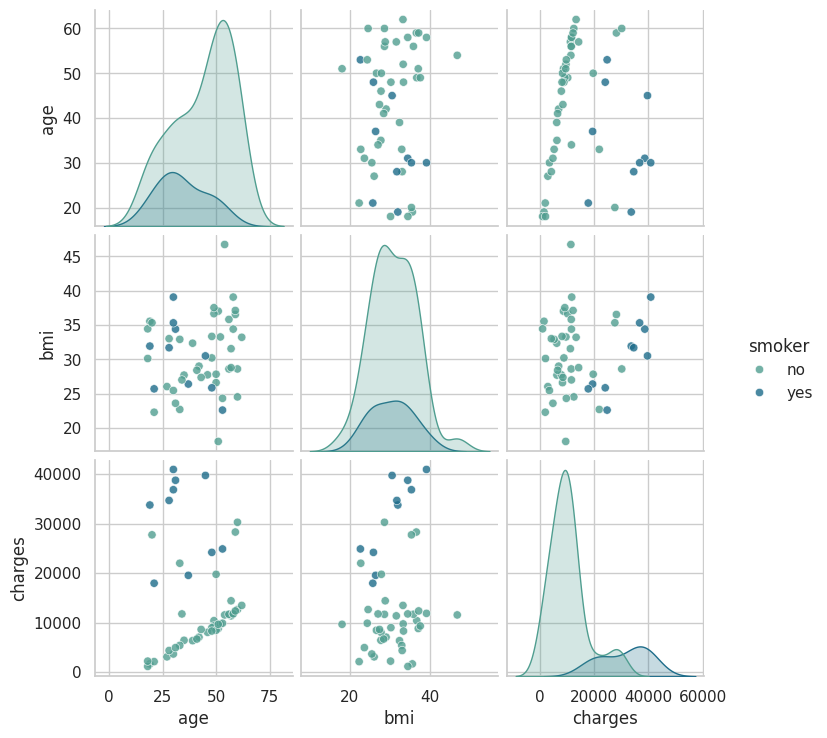

In [32]:
sns.pairplot(data=df, plot_kws={'alpha':0.8}, hue="smoker", palette='crest')
plt.show()

An alternative way to choose among the available palette options is to write any "wrong" option like: "xxxxx".
* It will produce an error, and it will suggest valid options that you can pick

```
ValueError: 'xxxxx' is not a valid value for name; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', ....
```

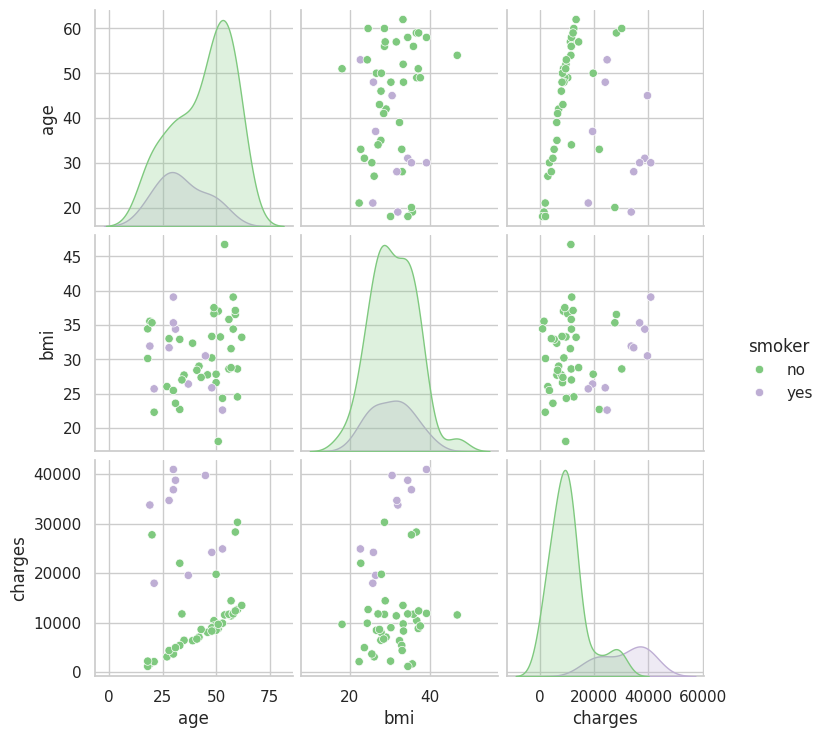

In [33]:
sns.pairplot(data=df, hue="smoker", palette='Accent')

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: We will use the DataFrame below, which uses the mpg dataset. It holds records for different car models and their attributes, like miles per gallon, model year, weight etc.

In [34]:
df_practice = sns.load_dataset('mpg')
df_practice = df_practice.sample(n=50, random_state=1)
df_practice.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
174,18.0,6,171.0,97.0,2984,14.5,75,usa,ford pinto
359,28.1,4,141.0,80.0,3230,20.4,81,europe,peugeot 505s turbo diesel
250,19.4,8,318.0,140.0,3735,13.2,78,usa,dodge diplomat


Feel free to try out your ideas using pair plot in this dataset

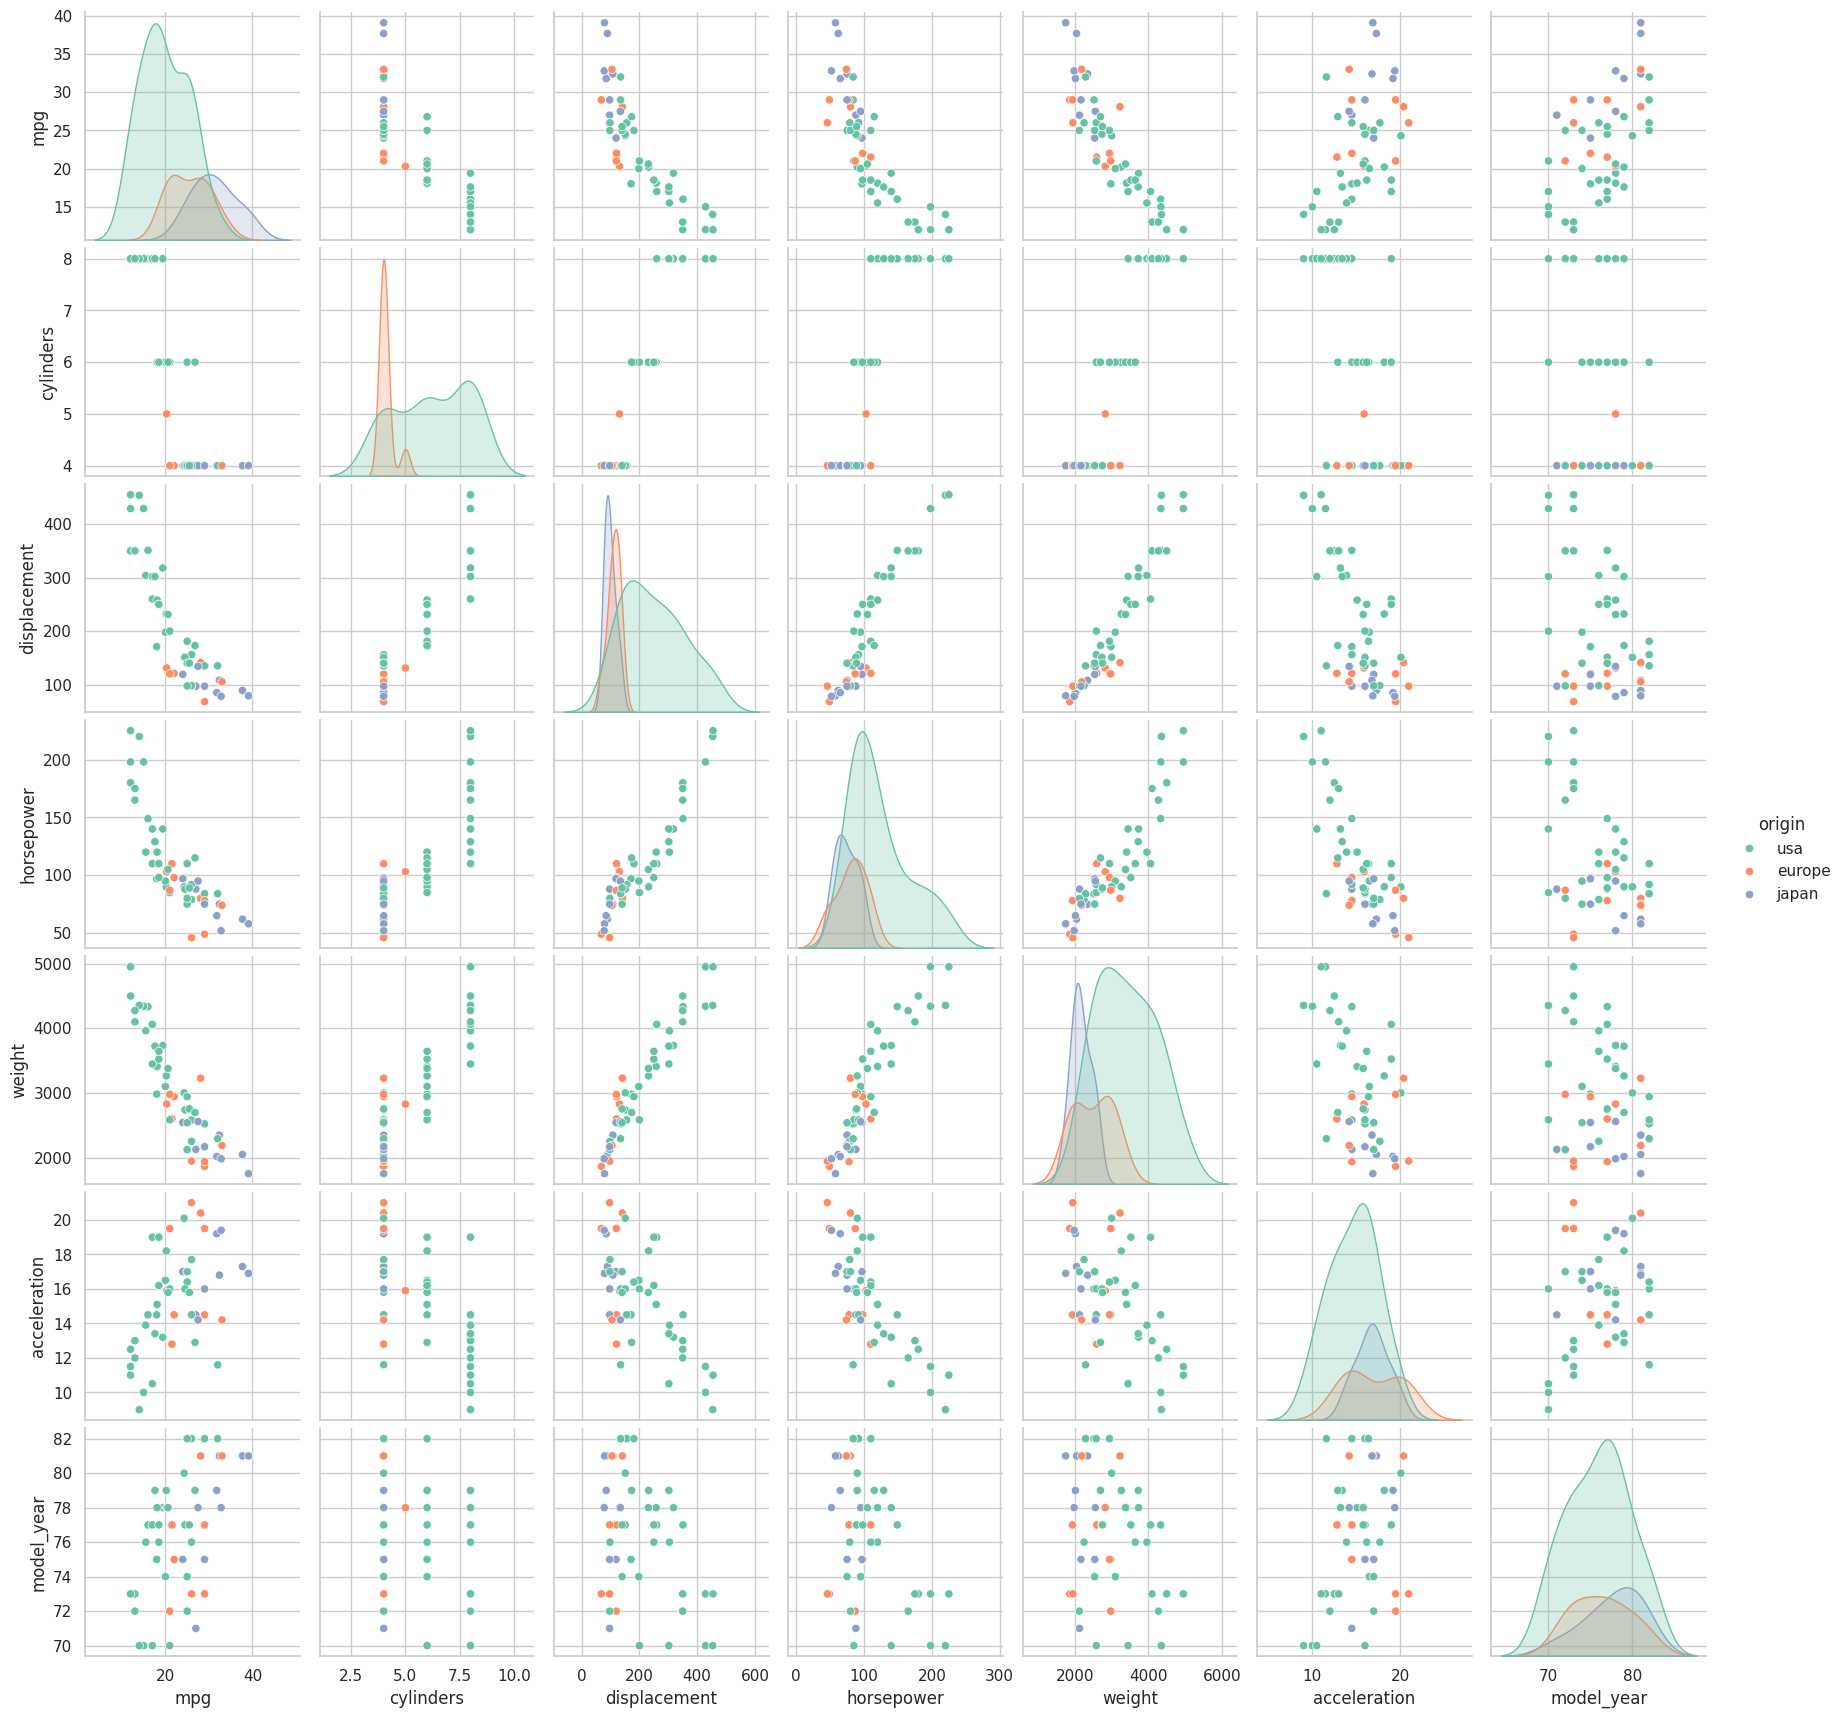

In [35]:
# write your code here
sns.pairplot(data=df_practice, hue='origin', palette='Set2')
plt.show()

---

Sometimes the feature space is so big that your Pair plot will add no value. You would have to subset only the variables you are most interested in to analyse them better.
* A criteria to select variables can be based on correlation analysis, which we will study in upcoming lessons